<a href="https://colab.research.google.com/github/psycholinguistics-proj/proj/blob/main/Relevant_Analysis_from_D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Run these first
`Ctrl` + `Enter` to run the cell and stay in that cell
`Shift` + `Enter` to run the cell and move to the next cell

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore


In [6]:
# Load the excel file from Drive
df = pd.read_excel('/content/drive/MyDrive/NLP/KLP_DB_final.xlsx', sheet_name='KLP_DB_final')

# Filter to words only
df_words = df[df['Lexicality'] == 1].copy()

# Log transform frequency
df_words['LogFreq'] = np.log(df_words['Freq'].replace('NA', np.nan).astype(float))


In [7]:
# Filtering the data to the correct sample
key_vars = ['MRT', 'MHIT', 'LogFreq', 'syltkn1', 'syltkn2', 'syllbdy1', 'syllbdy2', 'rhym1', 'rhym2']
df_words = df_words.dropna(subset=key_vars)
print(f'Full word sample: {len(df_words)} words')

# Restricted sample matching original paper (syllable freq 15-50 only on freq range, not syll freq)
df_restricted = df_words[(df_words['Freq'] >= 15) & (df_words['Freq'] <= 50)].copy()
print(f'Restricted sample (Freq 15-50): {len(df_restricted)} words')


Full word sample: 4565 words
Restricted sample (Freq 15-50): 1778 words


# Main Analysis

## Partial Regression
* Everything was put in simultaneously, but we still need to do hierarchical regression (variables need to be entered in steps so we can report ΔR² at each step - this is necessary to tell us how much additional variance `syltkn2` explains beyond LogFreq and `syltkn1` combined)
* This is only like a pilot analysis so we can see direction and rough magnitude of the effects.
* `syltkn1` effect > `syltkn2` effect (5.8 ms vs 2.5 ms - see coefficients). This is consistent with the serial processing account - the first syllable is processed first and drives most of the lexical competition. Alvarez et al. (2000) already predicted this for Spanish.
* Skew -> residuals (difference between what the regression model predicted and what actually happened aka `actual MRT - predicted MRT`) are not symmetrical. More large positive residudals
* Kurtosis -> residual distribution shows that there are more extreme values than expected
* `syltkn1` - 5.8 ms vs original paper's ~10.8 ms per SD because this one used the full word sample rather than the restricted low-frequency subset the paper used.
* 2.5 ms for `syltkn2` means that the second syllable contributes to lexical competition (but the effect is smaller than the first syllable effect)

In [11]:
# Partial regression plots
df_clean = df_words[['MRT', 'LogFreq', 'syltkn1', 'syltkn2']].dropna()
X = sm.add_constant(df_clean[['LogFreq', 'syltkn1', 'syltkn2']])
y = df_clean['MRT']

df_clean['LogFreq_z'] = zscore(df_clean['LogFreq'])
df_clean['syltkn1_z'] = zscore(df_clean['syltkn1'])
df_clean['syltkn2_z'] = zscore(df_clean['syltkn2'])

X_std = sm.add_constant(df_clean[['LogFreq_z', 'syltkn1_z', 'syltkn2_z']])
model_std = sm.OLS(df_clean['MRT'], X_std).fit()
print('***********************************************************************')
print("The model AFTER predictors were standardized")
print(model_std.summary())


***********************************************************************
The model AFTER predictors were standardized
                            OLS Regression Results                            
Dep. Variable:                    MRT   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.290
Method:                 Least Squares   F-statistic:                     622.0
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:43:45   Log-Likelihood:                -25840.
No. Observations:                4565   AIC:                         5.169e+04
Df Residuals:                    4561   BIC:                         5.171e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------

## MRT Hierarchical Analysis (full real word list + low-freq list)
* Full sample - both `syltkn1` and `syltkn2` are significant. ΔR² at Step 3 is small (0.0009).
* Restricted sample - p = .5151 means that `syltkn2` is not significant (when restricted to low-frequency words)

In [ ]:
# Main analysis: MRT models (hierarchical)

def run_hierarchical(df, dv='MRT'):
  df_c = df[['MRT', 'MHIT', 'LogFreq', 'syltkn1', 'syltkn2']].dropna()
  y = df_c[dv]

  # Step 1: control only
  m1 = sm.OLS(y, sm.add_constant(df_c[['LogFreq']])).fit()

  # Step 2: add syltkn1 (paper replication)
  m2 = sm.OLS(y, sm.add_constant(df_c[['LogFreq', 'syltkn1']])).fit()

  # Step 3: add syltkn2
  m3 = sm.OLS(y, sm.add_constant(df_c[['LogFreq', 'syltkn1', 'syltkn2']])).fit()

  print(f'\n--- {dv} Hierarchical Regression ---')
  print(f'Step 1: R²={m1.rsquared:.3f}')
  print(f'  LogFreq: β={m1.params["LogFreq"]:.4f}, p={m1.pvalues["LogFreq"]:.4f}')

  print(f'\nStep 2: R²={m2.rsquared:.3f}, ΔR²={m2.rsquared-m1.rsquared:.4f}')
  print(f'  LogFreq: β={m2.params["LogFreq"]:.4f}, p={m2.pvalues["LogFreq"]:.4f}')
  print(f'  syltkn1: β={m2.params["syltkn1"]:.6f}, p={m2.pvalues["syltkn1"]:.4f}')

  print(f'\nStep 3: R²={m3.rsquared:.3f}, ΔR²={m3.rsquared-m2.rsquared:.4f}')
  print(f'  LogFreq: β={m3.params["LogFreq"]:.4f}, p={m3.pvalues["LogFreq"]:.4f}')
  print(f'  syltkn1: β={m3.params["syltkn1"]:.6f}, p={m3.pvalues["syltkn1"]:.4f}')
  print(f'  syltkn2: β={m3.params["syltkn2"]:.6f}, p={m3.pvalues["syltkn2"]:.4f}')

  return m1, m2, m3

# Run on full sample
print('========= FULL SAMPLE =========')
m1, m2, m3 = run_hierarchical(df_words, dv='MRT')


# Run on restricted sample
print('\n========= RESTRICTED SAMPLE =========')
r1, r2, r3 = run_hierarchical(df_restricted, dv='MRT')


========= FULL SAMPLE =========

--- MRT Hierarchical Regression ---
Step 1: R²=0.285
  LogFreq: β=-33.1415, p=0.0000

Step 2: R²=0.289, ΔR²=0.0048
  LogFreq: β=-34.0503, p=0.0000
  syltkn1: β=0.000427, p=0.0000

Step 3: R²=0.290, ΔR²=0.0009
  LogFreq: β=-34.3585, p=0.0000
  syltkn1: β=0.000425, p=0.0000
  syltkn2: β=0.000186, p=0.0168

========= RESTRICTED SAMPLE =========

--- MRT Hierarchical Regression ---
Step 1: R²=0.019
  LogFreq: β=-32.1969, p=0.0000

Step 2: R²=0.025, ΔR²=0.0055
  LogFreq: β=-32.8002, p=0.0000
  syltkn1: β=0.000494, p=0.0016

Step 3: R²=0.025, ΔR²=0.0002
  LogFreq: β=-32.7859, p=0.0000
  syltkn1: β=0.000491, p=0.0016
  syltkn2: β=0.000103, p=0.5151


### MHIT Hierarchical Regression (including MHIT <100)
* negative coefficients mean that higher syllable token is associated with lower accuracy. (Makes sense: more competition -> more errors)
* Suggests speed and accuracy are being affected by the same mechanism, *not dissociating*.


In [ ]:
# Parallel MHIT models
print('========= FULL SAMPLE =========')
mhit1, mhit2, mhit3 = run_hierarchical(df_words, dv='MHIT')

# Sub-ceiling (MHIT < 100)
df_subceil = df_words[df_words['MHIT'] < 100].copy()
print(f'\nSub-ceiling sample: {len(df_subceil)} words')
print('========= SUB-CEILING SAMPLE - MHIT =========')
mhit_s1, mhit_s2, mhit_s3 = run_hierarchical(df_subceil, dv='MHIT')

========= FULL SAMPLE =========

--- MHIT Hierarchical Regression ---
Step 1: R²=0.174
  LogFreq: β=6.3846, p=0.0000

Step 2: R²=0.179, ΔR²=0.0044
  LogFreq: β=6.5970, p=0.0000
  syltkn1: β=-0.000100, p=0.0000

Step 3: R²=0.181, ΔR²=0.0021
  LogFreq: β=6.7142, p=0.0000
  syltkn1: β=-0.000099, p=0.0000
  syltkn2: β=-0.000071, p=0.0006

Sub-ceiling sample: 3356 words
========= SUB-CEILING SAMPLE - MHIT =========

--- MHIT Hierarchical Regression ---
Step 1: R²=0.146
  LogFreq: β=7.3533, p=0.0000

Step 2: R²=0.150, ΔR²=0.0043
  LogFreq: β=7.5724, p=0.0000
  syltkn1: β=-0.000108, p=0.0000

Step 3: R²=0.152, ΔR²=0.0021
  LogFreq: β=7.6774, p=0.0000
  syltkn1: β=-0.000107, p=0.0000
  syltkn2: β=-0.000076, p=0.0043


## Effect Sizes (ms per SD) for MRT and MHIT

In [ ]:
# Get SDs
sd_syltkn1 = df_words['syltkn1'].std()
sd_syltkn2 = df_words['syltkn2'].std()
sd_logfreq = df_words['LogFreq'].std()


# Access coefficients directly from the model object
print('=== MRT Step 3 — effect sizes ===')
print(f'LogFreq:  {m3.params["LogFreq"] * sd_logfreq:.2f} ms per SD')
print(f'syltkn1:  {m3.params["syltkn1"] * sd_syltkn1:.2f} ms per SD')
print(f'syltkn2:  {m3.params["syltkn2"] * sd_syltkn2:.2f} ms per SD')

print()
print('=== MHIT sub-ceiling Step 3 — effect sizes ===')
print(f'LogFreq:  {mhit_s3.params["LogFreq"] * sd_logfreq:.2f} % per SD')
print(f'syltkn1:  {mhit_s3.params["syltkn1"] * sd_syltkn1:.2f} % per SD')
print(f'syltkn2:  {mhit_s3.params["syltkn2"] * sd_syltkn2:.2f} % per SD')

=== MRT Step 3 — effect sizes ===
LogFreq:  -45.64 ms per SD
syltkn1:  5.83 ms per SD
syltkn2:  2.50 ms per SD

=== MHIT sub-ceiling Step 3 — effect sizes ===
LogFreq:  10.20 % per SD
syltkn1:  -1.47 % per SD
syltkn2:  -1.02 % per SD


### Overall Findings from Phase 1
1. Replication of effect of first-syllable token freq on MRT replicates in both the full sample and restricted low-freq sample. Consistent with the original paper.
2. Second-syllable token freq predicts MRT in the full sample (β = +0.000186, p = .017, which was standardized to +2.50ms per standard deviation). Suggests second-syllable competition contributes additional inhibition. Consistent with partial parallel processing?
**IMPORTANT NOTE**: effect does not replicate in restricted low-freq sample (p = .515)
3. Both `syltkn1` and `syltkn2` significantly predict MHIT in the negative direction in both the full sample and sub-ceiling (MHIT < 100) sample. Speed and accuracy are not dissociating (they are affected by the same mechanism)
4. `Freq` x `syltkn2` is not significant. The second-syllable effect does nto vary as a function of word frequency.

## Frequency Quartile

In [ ]:
# Create frequency quartiles
# Only use words that have Freq data (not NA)
df_q = df_words[['MRT', 'LogFreq', 'syltkn1', 'syltkn2', 'Freq']].dropna().copy()

df_q['FreqQuartile'] = pd.qcut(df_q['Freq'],
                                q=4,
                                labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

# Check how many words per quartile
print('Words per quartile:')
print(df_q['FreqQuartile'].value_counts().sort_index())
print()

# Run regression within each quartile
sd_syltkn2 = df_words['syltkn2'].std()
results = []
print(f'{"Quartile":<15} {"n":>5} {"syltkn2 β":>12} {"SE":>10} {"t":>8} {"p":>8} {"sig":>6} {"   | effect (ms per SD)":>6}')
print('-' * 95)

for q in ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']:
    subset = df_q[df_q['FreqQuartile'] == q]
    X = sm.add_constant(subset[['LogFreq', 'syltkn1', 'syltkn2']])
    m = sm.OLS(subset['MRT'], X).fit()

    b = m.params['syltkn2']
    se = m.bse['syltkn2']
    t = m.tvalues['syltkn2']
    p = m.pvalues['syltkn2']
    ci_low = m.conf_int().loc['syltkn2', 0]
    ci_high = m.conf_int().loc['syltkn2', 1]
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'
    effect = b * sd_syltkn2

    print(f'{q:<15} {len(subset):>5} {b:>12.6f} {se:>10.6f} {t:>8.3f} {p:>8.4f}  {sig:>7}  | {effect:>8.2f}')

    results.append({
        'quartile': q,
        'n': len(subset),
        'beta': b,
        'se': se,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'p': p,
        'sig': sig
    })

print()
print('Freq range per quartile:')
for q in ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']:
    subset = df_q[df_q['FreqQuartile'] == q]
    print(f'{q}: Freq {subset["Freq"].min():.0f} – {subset["Freq"].max():.0f}')

Words per quartile:
FreqQuartile
Q1 (lowest)     1176
Q2              1120
Q3              1129
Q4 (highest)    1140
Name: count, dtype: int64

Quartile            n    syltkn2 β         SE        t        p    sig    | effect (ms per SD)
-----------------------------------------------------------------------------------------------
Q1 (lowest)      1176    -0.000058   0.000198   -0.294   0.7690     n.s.  |    -0.78
Q2               1120     0.000551   0.000174    3.169   0.0016       **  |     7.38
Q3               1129     0.000162   0.000141    1.143   0.2531     n.s.  |     2.17
Q4 (highest)     1140     0.000070   0.000098    0.715   0.4749     n.s.  |     0.94

Freq range per quartile:
Q1 (lowest): Freq 3 – 33
Q2: Freq 34 – 73
Q3: Freq 74 – 209
Q4 (highest): Freq 210 – 16768


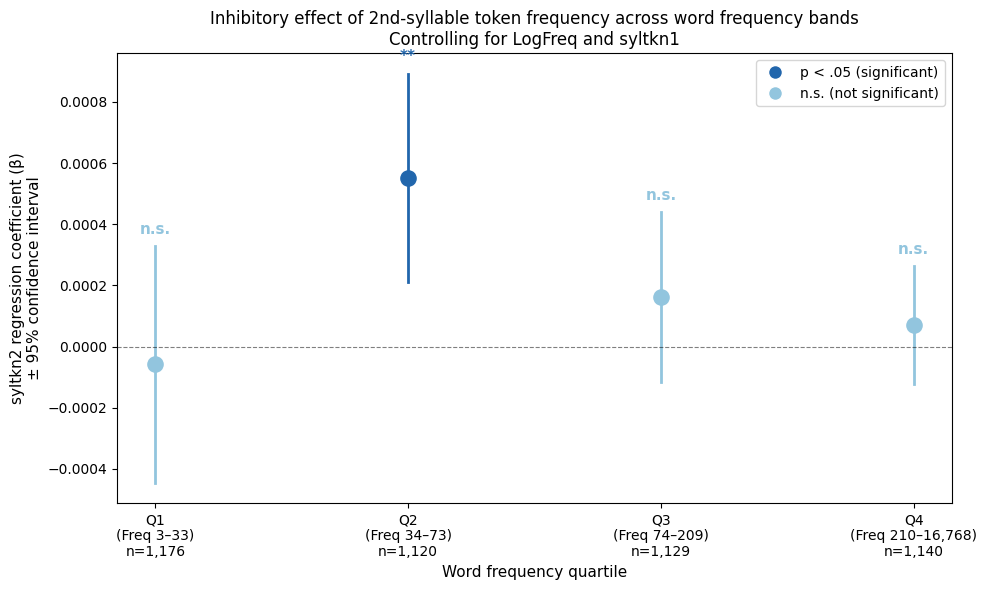

In [ ]:
quartiles = ['Q1\n(Freq 3–33)\nn=1,176',
             'Q2\n(Freq 34–73)\nn=1,120',
             'Q3\n(Freq 74–209)\nn=1,129',
             'Q4\n(Freq 210–16,768)\nn=1,140']

betas = [r['beta'] for r in results]
ci_lows = [r['ci_low'] for r in results]
ci_highs = [r['ci_high'] for r in results]
pvals = [r['p'] for r in results]
sigs = [r['sig'] for r in results]

# Colors: significant = darker, n.s. = lighter
colors = ['#2166ac' if p < .05 else '#92c5de' for p in pvals]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(quartiles))

# Plot confidence interval lines first
for i in range(len(quartiles)):
    ax.plot([x[i], x[i]], [ci_lows[i], ci_highs[i]],
            color=colors[i], linewidth=2, zorder=2)

# Plot beta dots
for i in range(len(quartiles)):
    ax.scatter(x[i], betas[i],
               color=colors[i], s=120, zorder=3,
               label='p < .05' if pvals[i] < .05 else 'n.s.')

# Zero reference line
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Significance labels above each point
for i in range(len(quartiles)):
    y_pos = ci_highs[i] + 0.00003
    ax.text(x[i], y_pos, sigs[i],
            ha='center', va='bottom', fontsize=11,
            color=colors[i], fontweight='bold')

# Axis labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(quartiles, fontsize=10)
ax.set_ylabel('syltkn2 regression coefficient (β)\n± 95% confidence interval', fontsize=11)
ax.set_xlabel('Word frequency quartile', fontsize=11)
ax.set_title('Inhibitory effect of 2nd-syllable token frequency across word frequency bands\n'
             'Controlling for LogFreq and syltkn1', fontsize=12)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2166ac',
           markersize=10, label='p < .05 (significant)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#92c5de',
           markersize=10, label='n.s. (not significant)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('quartile_syltkn2_effect.png', dpi=150, bbox_inches='tight')
plt.show()